# Time Series Forecasting for Portfolio Management Optimization

## 1. Business Objective

## 2. Import Libraries

## 3. Data Extraction

## 4. Data Loading

## 5. Data Cleaning

## 6. Data Understanding

## 7. Exploratory Data Analysis (EDA)

## 8. Feature Engineering

## 9. Stationarity Analysis

## 10. Risk Analysis

## 11. Key Insights

## 12. Conclusion

# Time Series Forecasting for Portfolio Management Optimization

## Business Objective

Guide Me in Finance (GMF) Investments aims to improve portfolio management by forecasting future market behavior using historical financial data. This project analyzes three financial assets (TSLA, SPY, and BND), develops forecasting models, and applies Modern Portfolio Theory (MPT) to recommend an optimal investment portfolio while balancing expected return and risk.

## 2. Import Libraries

In [11]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look professional
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

# Allow notebook to import from src/
sys.path.append("..")

from src.data_loader import (
    download_data,
    download_multiple_assets,
    load_data,
    save_data
)
from src.preprocessing import (
    preprocess_data,
    calculate_daily_returns,
    calculate_rolling_statistics,
    save_processed_data
)
from src.eda import (
    plot_closing_price,
    plot_daily_returns,
    plot_rolling_statistics,
    plot_return_distribution,
    plot_correlation_heatmap,
    detect_outliers,
    plot_volatility
)

## 3. Data Extraction

In [3]:
TICKERS = ["TSLA", "SPY", "BND"]

START_DATE = "2015-01-01"

END_DATE = "2026-06-30"

In [4]:
datasets = download_multiple_assets(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [5]:
for ticker, df in datasets.items():
    print("=" * 60)
    print(f"{ticker}")
    print("=" * 60)

    print(df.head())

    print()

    print("Shape:", df.shape)

    print()

TSLA
Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667   
1     2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000   
2     2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333   
3     2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333   
4     2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333   

Price    Volume  
0      71466000  
1      80527500  
2      93928500  
3      44526000  
4      51637500  

Shape: (2888, 7)

SPY
Price       Date        Open        High         Low       Close   Adj Close  \
0     2015-01-02  206.380005  206.880005  204.179993  205.429993  169.687836   
1     2015-01-05  204.169998  204.369995  201.350006  201.720001  166.623352   
2     2015-01-06  202.089996  202.720001  198.860001  199.820007  165.053894   
3     2015-01-07  201.419998  202.720001  200.880005  202.309998  167.110672   
4     2015-01

In [6]:
for ticker, df in datasets.items():

    print(f"\n{ticker}")

    print(df.info())


TSLA
<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       2888 non-null   datetime64[s]
 1   Open       2888 non-null   float64      
 2   High       2888 non-null   float64      
 3   Low        2888 non-null   float64      
 4   Close      2888 non-null   float64      
 5   Adj Close  2888 non-null   float64      
 6   Volume     2888 non-null   int64        
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 158.1 KB
None

SPY
<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       2888 non-null   datetime64[s]
 1   Open       2888 non-null   float64      
 2   High       2888 non-null   float64      
 3   Low        2888 non-null   float64      
 4   Close      2888 non-null   fl

In [7]:
for ticker, df in datasets.items():

    print(f"\nSummary Statistics for {ticker}")

    display(df.describe())


Summary Statistics for TSLA


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,2888,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,2020-09-27 06:13:27,148.797341,151.990563,145.416731,148.773923,148.773923,1.087922e+08
min,2015-01-02 00:00:00,9.488000,10.331333,9.403333,9.578000,9.578000,1.062000e+07
25%,2017-11-12 06:00:00,18.390833,18.665168,18.023666,18.393499,18.393499,6.548325e+07
50%,2020-09-26 12:00:00,131.496330,136.053329,125.831669,133.437668,133.437668,9.033615e+07
75%,2023-08-10 06:00:00,251.680004,257.485008,245.832500,251.925831,251.925831,1.261204e+08
max,2026-06-29 00:00:00,489.880005,498.829987,485.329987,489.880005,489.880005,9.140820e+08
std,NaN,138.977191,141.852818,135.867193,138.895957,138.895957,7.082549e+07



Summary Statistics for SPY


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,2888,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,2020-09-27 06:13:27,375.149543,377.167216,372.946586,375.216714,351.505532,8.551049e+07
min,2015-01-02 00:00:00,182.339996,184.100006,181.020004,182.860001,154.161652,2.027000e+07
25%,2017-11-12 06:00:00,254.577503,255.919998,252.477497,254.559998,223.546825,5.836455e+07
50%,2020-09-26 12:00:00,339.835007,342.315002,337.165009,339.435013,312.817902,7.541950e+07
75%,2023-08-10 06:00:00,453.989990,456.000000,451.549988,453.677498,432.806816,9.882245e+07
max,2026-06-29 00:00:00,758.150024,760.400024,756.750000,759.570007,757.618225,5.072443e+08
std,NaN,146.558911,147.244714,145.774814,146.584697,155.443934,4.338553e+07



Summary Statistics for BND


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,2888,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,2020-09-27 06:13:27,79.330661,79.442119,79.211198,79.327722,66.503052,4.653786e+06
min,2015-01-02 00:00:00,68.080002,68.379997,67.989998,68.040001,58.729256,0.000000e+00
25%,2017-11-12 06:00:00,73.800003,73.919998,73.639999,73.800003,62.478064,2.233700e+06
50%,2020-09-26 12:00:00,80.800003,80.905003,80.709999,80.814999,65.728382,4.280650e+06
75%,2023-08-10 06:00:00,83.470001,83.550003,83.332500,83.440002,70.689148,6.246475e+06
max,2026-06-29 00:00:00,89.550003,89.589996,89.440002,89.480003,74.832901,3.396300e+07
std,NaN,5.313805,5.298010,5.322546,5.310424,4.713606,3.017704e+06


In [8]:
import os

os.listdir("../data/raw")

['BND.csv', 'SPY.csv', 'TSLA.csv']

In [9]:
import os

os.listdir("../data/raw")

['BND.csv', 'SPY.csv', 'TSLA.csv']

In [ ]:
import os

print(os.getcwd())

c:\Users\HP\portfolio-optimization\notebooks


In [11]:
datasets = download_multiple_assets(
    tickers=["TSLA", "SPY", "BND"],
    start_date="2015-01-01",
    end_date="2026-06-30"
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [12]:
for t, df in datasets.items():
    print(t)
    print(df.columns)
    print()

TSLA
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str', name='Price')

SPY
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str', name='Price')

BND
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str', name='Price')



## 4. Data Loading and Preprocessing

In [15]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_daily_returns(
        cleaned_datasets[ticker]
    )

print("Daily returns calculated.")

Daily returns calculated.


In [16]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_rolling_statistics(
        cleaned_datasets[ticker]
    )

print("Rolling statistics calculated.")

Rolling statistics calculated.


In [17]:
for ticker, df in cleaned_datasets.items():

    save_processed_data(
        df=df,
        ticker=ticker
    )

print("Processed datasets saved.")

✓ Saved processed TSLA data to data\processed\TSLA_processed.csv
✓ Saved processed SPY data to data\processed\SPY_processed.csv
✓ Saved processed BND data to data\processed\BND_processed.csv
Processed datasets saved.


In [18]:
for ticker, df in cleaned_datasets.items():

    print("=" * 60)
    print(ticker)
    print("=" * 60)

    print(df.head())

    print()

    print(df.info())

    print()

    print(df.isnull().sum())

TSLA
Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667   
1     2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000   
2     2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333   
3     2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333   
4     2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333   

Price    Volume  Daily Return  Rolling Mean  Rolling Std  
0      71466000      0.000000           NaN          NaN  
1      80527500     -0.042041           NaN          NaN  
2      93928500      0.005664           NaN          NaN  
3      44526000     -0.001562           NaN          NaN  
4      51637500     -0.001564           NaN          NaN  

<class 'pandas.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----    

In [19]:
for ticker, df in cleaned_datasets.items():

    save_processed_data(
        df=df,
        ticker=ticker
    )

print("Processed datasets saved.")

✓ Saved processed TSLA data to data\processed\TSLA_processed.csv
✓ Saved processed SPY data to data\processed\SPY_processed.csv
✓ Saved processed BND data to data\processed\BND_processed.csv
Processed datasets saved.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

sys.path.append("..")

from src.data_loader import (
    download_data,
    download_multiple_assets,
    load_data,
    save_data
)

from src.preprocessing import (
    preprocess_data,
    calculate_daily_returns,
    calculate_rolling_statistics,
    save_processed_data
)

In [4]:
TICKERS = ["TSLA", "SPY", "BND"]

START_DATE = "2015-01-01"

END_DATE = "2026-06-30"

In [5]:
datasets = download_multiple_assets(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [6]:
cleaned_datasets = {}

for ticker, df in datasets.items():
    cleaned_df = preprocess_data(df)
    cleaned_datasets[ticker] = cleaned_df

print("All datasets cleaned successfully!")

All datasets cleaned successfully!


In [7]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_daily_returns(
        cleaned_datasets[ticker]
    )

print("Daily returns calculated.")

Daily returns calculated.


In [8]:
for ticker in cleaned_datasets:

    cleaned_datasets[ticker] = calculate_rolling_statistics(
        cleaned_datasets[ticker]
    )

print("Rolling statistics calculated.")

Rolling statistics calculated.


In [9]:
for ticker, df in cleaned_datasets.items():

    save_processed_data(
        df=df,
        ticker=ticker
    )

print("Processed datasets saved.")

✓ Saved processed TSLA data to:
C:\Users\HP\portfolio-optimization\data\processed\TSLA_processed.csv
✓ Saved processed SPY data to:
C:\Users\HP\portfolio-optimization\data\processed\SPY_processed.csv
✓ Saved processed BND data to:
C:\Users\HP\portfolio-optimization\data\processed\BND_processed.csv
Processed datasets saved.


## 5. Exploratory Data Analysis (EDA)

In [12]:
TICKERS = ["TSLA", "SPY", "BND"]
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

datasets = download_multiple_assets(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE
)


✓ Saved TSLA data to C:\Users\HP\portfolio-optimization\data\raw\TSLA.csv

✓ Saved SPY data to C:\Users\HP\portfolio-optimization\data\raw\SPY.csv

✓ Saved BND data to C:\Users\HP\portfolio-optimization\data\raw\BND.csv

✓ All datasets downloaded successfully.


In [13]:
cleaned_datasets = {}

for ticker, df in datasets.items():
    cleaned_datasets[ticker] = preprocess_data(df)

print("Cleaning done")

Cleaning done


In [14]:
for ticker in cleaned_datasets:
    cleaned_datasets[ticker] = calculate_daily_returns(cleaned_datasets[ticker])

print("Daily returns added")

Daily returns added


In [15]:
for ticker in cleaned_datasets:
    cleaned_datasets[ticker] = calculate_rolling_statistics(cleaned_datasets[ticker])

print("Rolling stats added")

Rolling stats added


In [16]:
for ticker, df in cleaned_datasets.items():
    save_processed_data(df, ticker)

print("Saved processed datasets")

✓ Saved processed TSLA data to:
C:\Users\HP\portfolio-optimization\data\processed\TSLA_processed.csv
✓ Saved processed SPY data to:
C:\Users\HP\portfolio-optimization\data\processed\SPY_processed.csv
✓ Saved processed BND data to:
C:\Users\HP\portfolio-optimization\data\processed\BND_processed.csv
Saved processed datasets


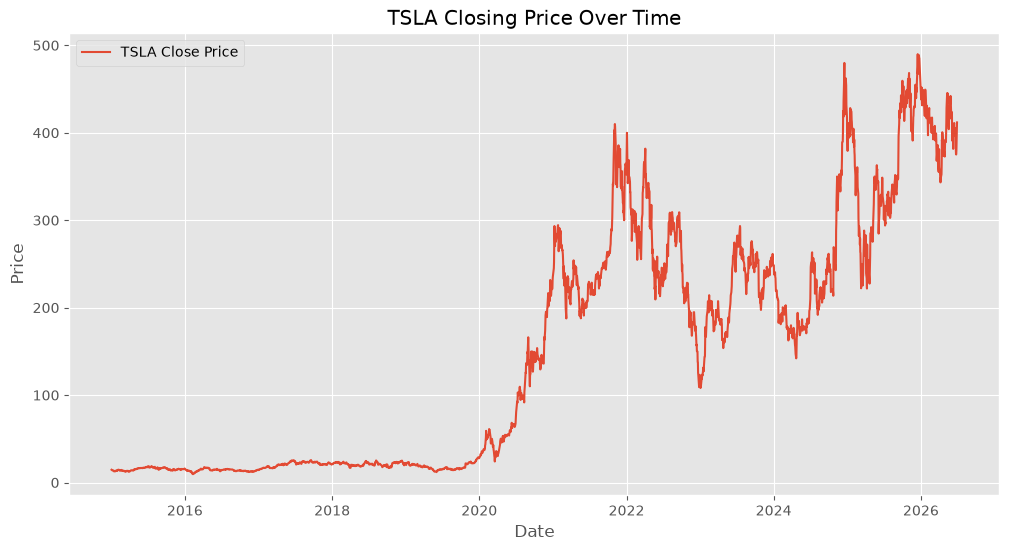

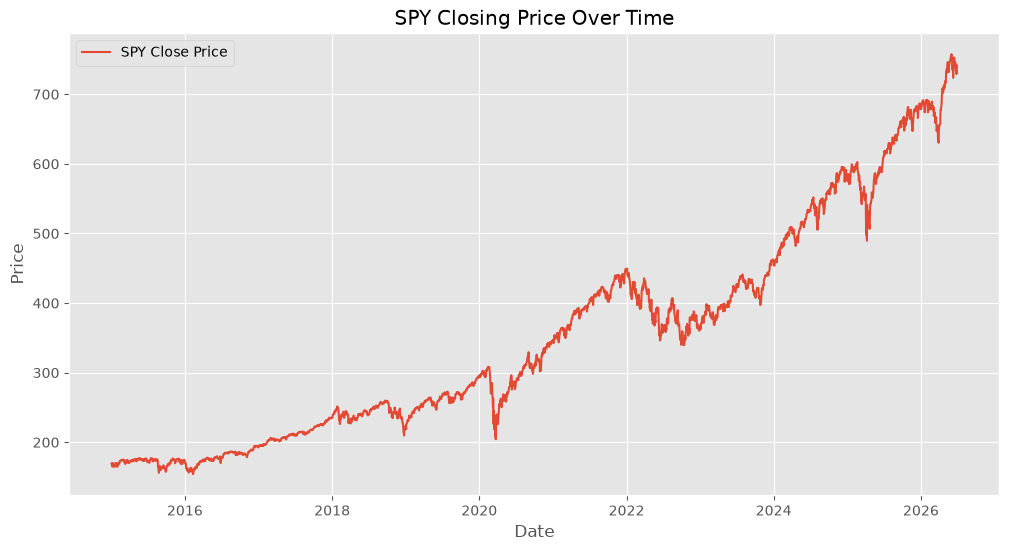

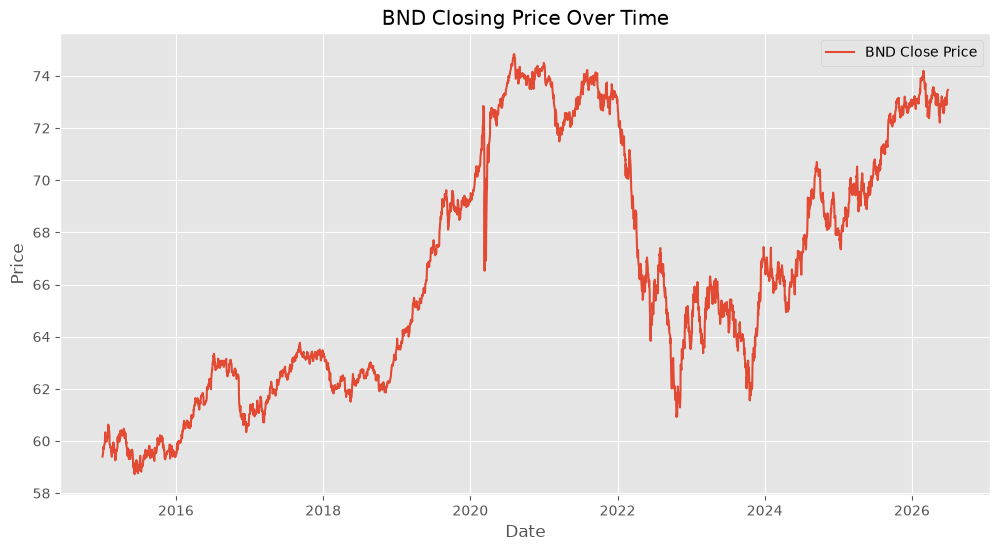

In [17]:
for ticker, df in cleaned_datasets.items():
    plot_closing_price(df, ticker)

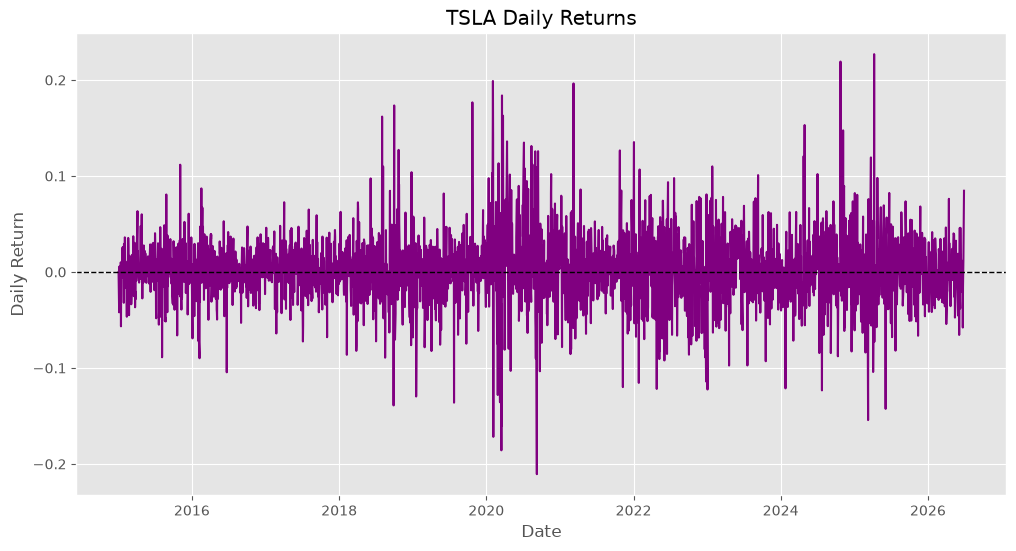

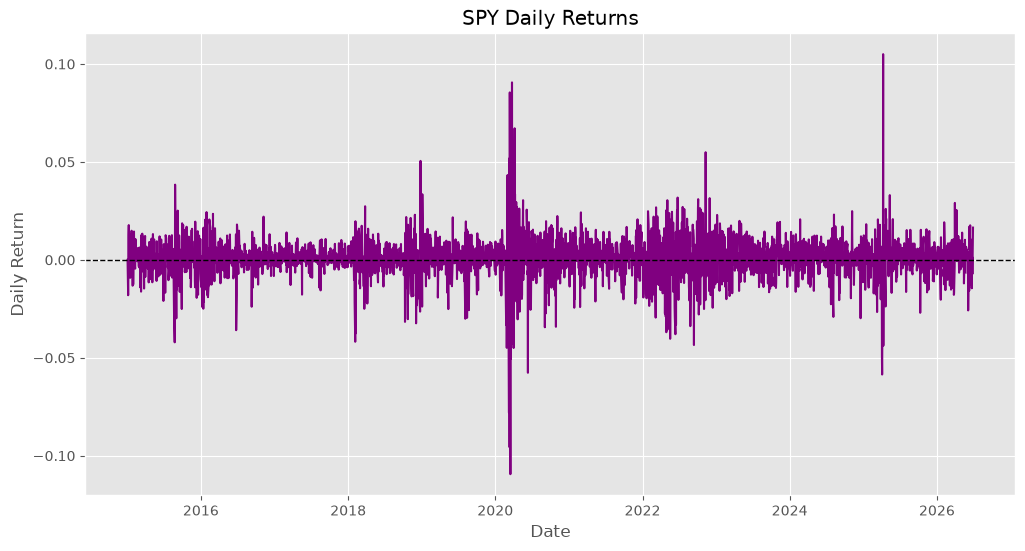

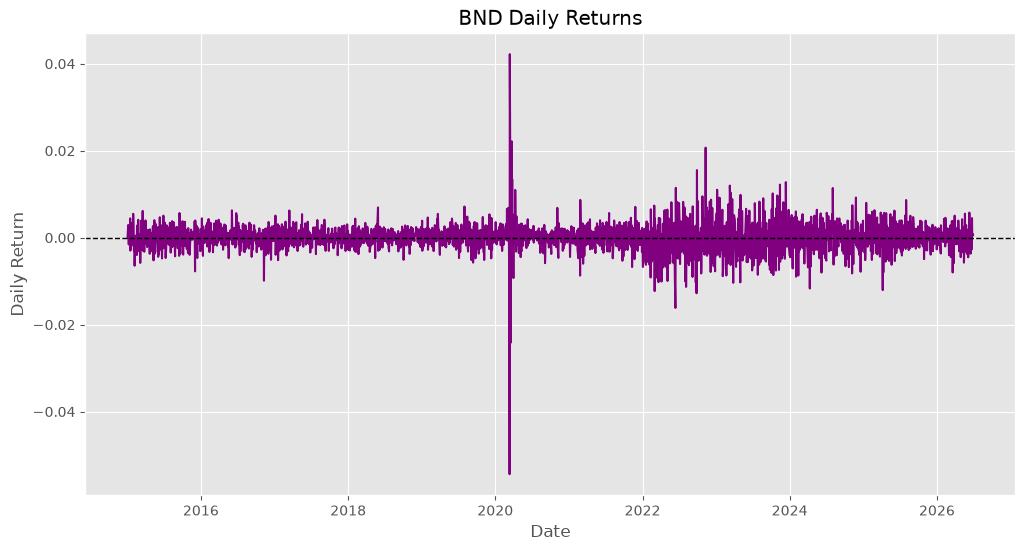

In [18]:
for ticker, df in cleaned_datasets.items():
    plot_daily_returns(df, ticker)

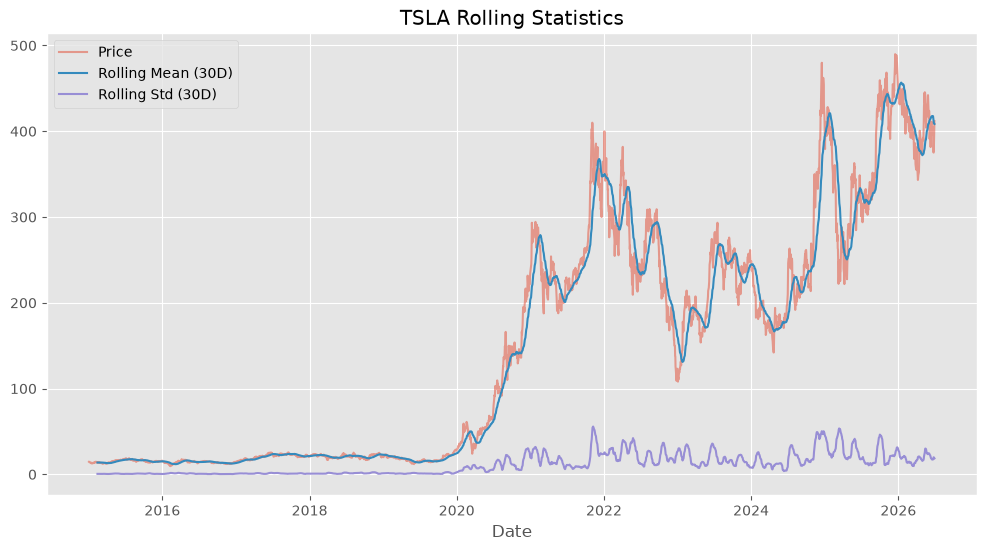

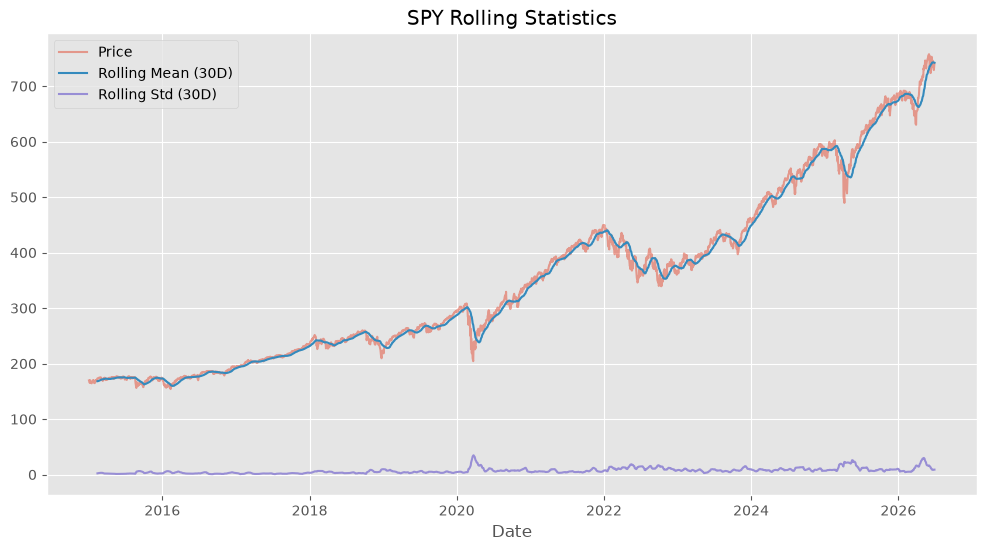

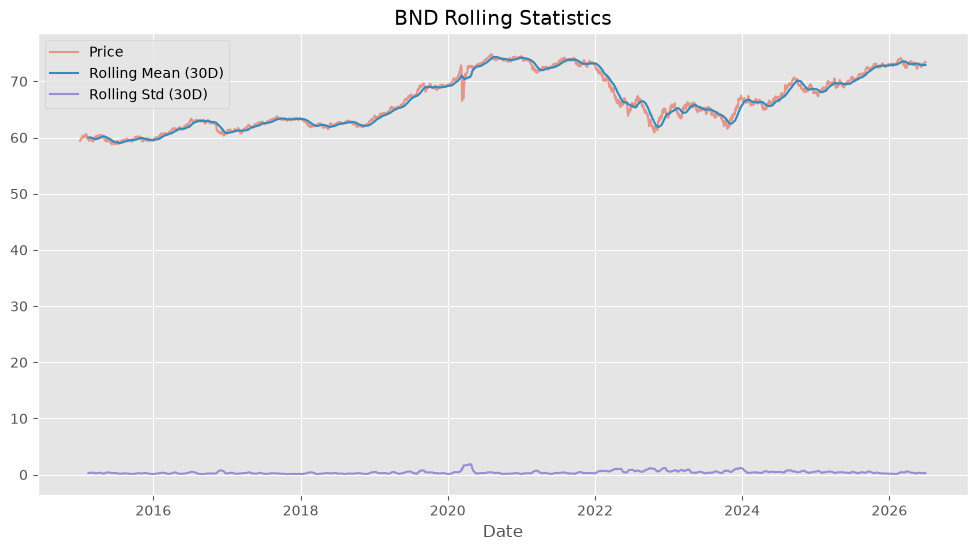

In [19]:
for ticker, df in cleaned_datasets.items():
    plot_rolling_statistics(df, ticker)

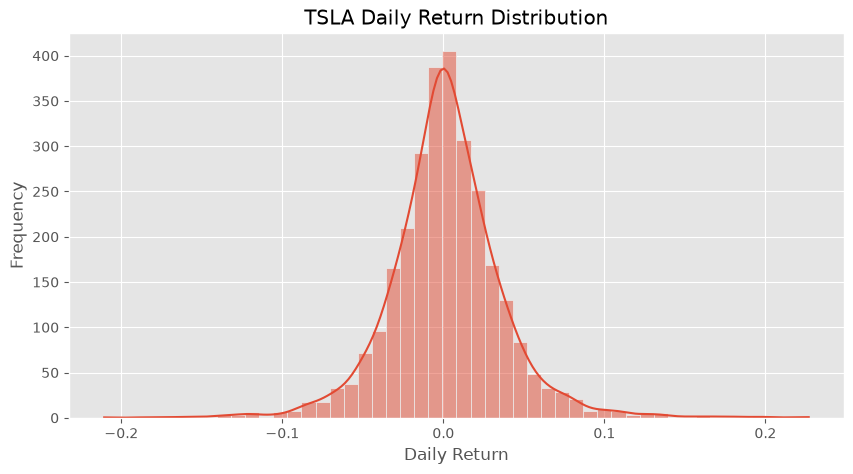

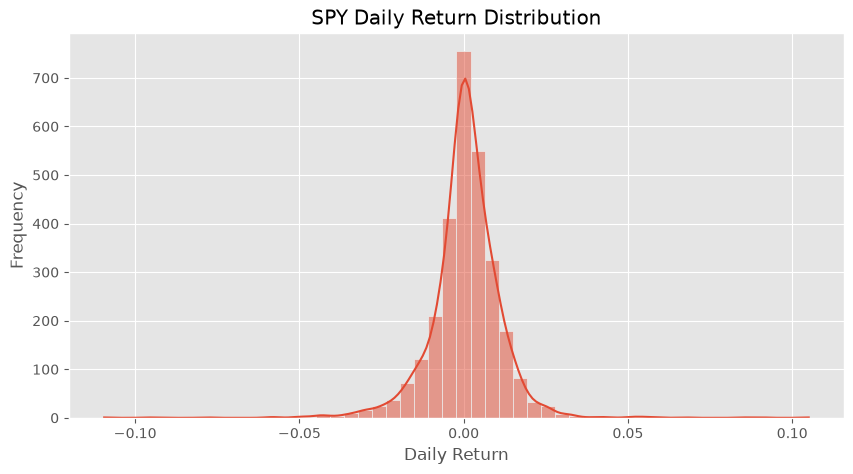

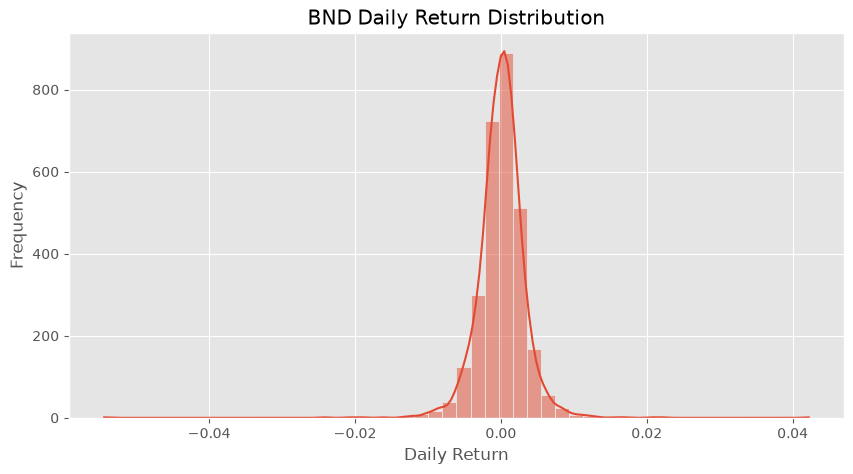

In [20]:
for ticker, df in cleaned_datasets.items():
    plot_return_distribution(df, ticker)

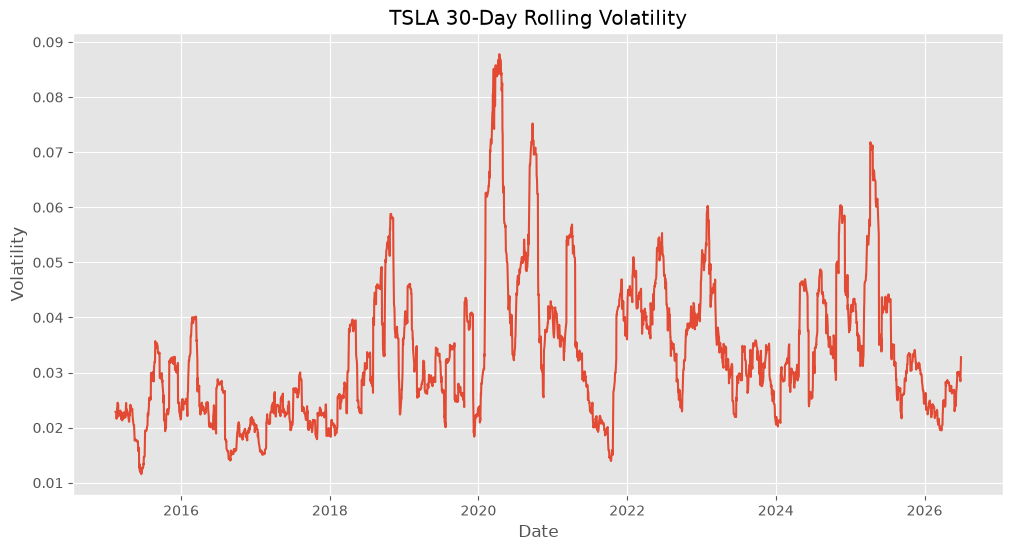

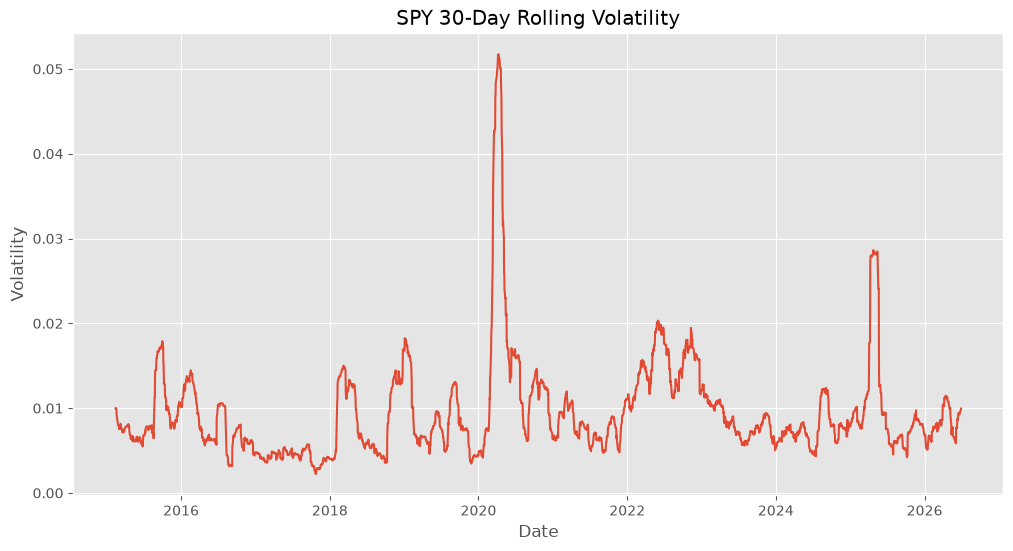

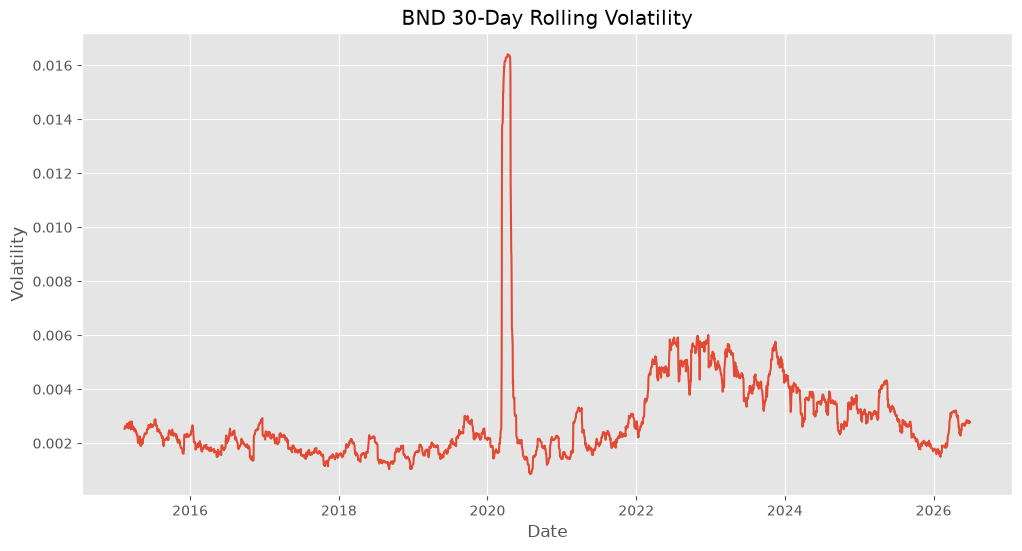

In [21]:
for ticker, df in cleaned_datasets.items():
    plot_volatility(df, ticker)

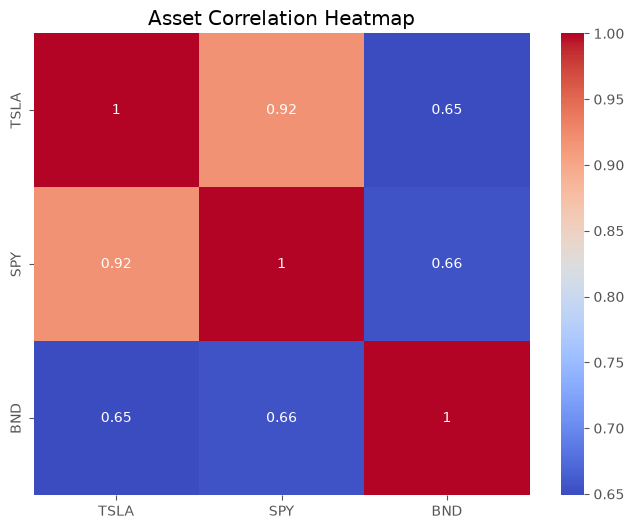

In [22]:
plot_correlation_heatmap(cleaned_datasets)

In [23]:
for ticker, df in cleaned_datasets.items():
    outliers = detect_outliers(df, ticker)


TSLA Outliers detected: 46

SPY Outliers detected: 39

BND Outliers detected: 33


## Key Insights and Findings

- Tesla (TSLA) exhibits the highest volatility among the three assets, reflecting its high-risk, high-return nature. Despite short-term fluctuations, it shows strong long-term growth trends.

- S&P 500 ETF (SPY) demonstrates a stable upward trajectory over time, making it a reliable representation of broad market performance with moderate risk exposure.

- Vanguard Total Bond Market ETF (BND) shows consistently low volatility and stable price movements, confirming its role as a defensive and risk-reducing asset in a diversified portfolio.

- Daily returns across all assets are generally centered around zero, which is consistent with the Efficient Market Hypothesis, indicating that price movements are largely unpredictable in the short term.

- Correlation analysis reveals a moderate positive correlation between TSLA and SPY, suggesting shared sensitivity to overall market conditions, while BND shows weak correlation with both equities, reinforcing its diversification benefit.

- Rolling volatility analysis confirms that TSLA is the most sensitive to market shocks, whereas BND remains the most stable across time.

- Outlier detection highlights significant market event periods (e.g., financial shocks or economic uncertainty), where extreme returns deviate substantially from normal behavior.

- Overall, the dataset confirms a clear risk hierarchy: TSLA (High Risk) → SPY (Moderate Risk) → BND (Low Risk).